In [2]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path, then adjust model to use level1 and level2, make model_train_validate.ipynb
## 2026.03.24 make it fit NCRT all ROIs

In [3]:
import sys
import os
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
import model
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  
importlib.reload(model)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    loader_train_test,
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
# therapy_model = f'{therapy_data}_project_tumor1'
therapy_model = f'{therapy_data}_project_all'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'

Successfully reloaded functions from base.py
openslide: False, tifffile: True


In [4]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    device = torch.device("cuda")
    # Reproducibility-first: use deterministic cuDNN settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == "cuda" else ""))



## Reproducibility setup (run this first after kernel restart)
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
# Needed by CUDA for deterministic GEMM on some ops.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Enforce deterministic behavior (may reduce speed).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


## Cell Type Classification Model

In [5]:
# ## Tumor1: Match embeddings with celltype data by coordinates
# cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_tumor1.csv'
# hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1/sc_pth_16_16')
# matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_test0.npz'

## All: Match embeddings with celltype data by coordinates
cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_all/sc_pth_16_16')
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_all.npz'


match_tolerance = 1.0
X, y, y_level1, X_coords_matched = match_hist2cell_matrix(
    cell_coords_path,
    hist_embedding_dir,
    matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),    # HE coordinates
    tolerance=match_tolerance,
    pth_prefix=f"sc_{therapy_data}",
)


Loading celltype Ground Truth ...


  Loaded 1746948 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/matched_features_all.npz
  X shape: (1746948, 384)
  y shape: (1746948,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (1746948, 2)


In [6]:
result = split_train_test(X, y, y_level1)

# Keep only widely used metadata as top-level variables.
class_names = result["class_names"]
class_names_level1 = result["class_names_level1"]
le_level2 = result["le_level2"]
le_level1 = result["le_level1"]
scaler = result["scaler"]


Train/Test split:
  Training set: 1222863 samples
  Test set: 524085 samples
  Feature dimension: 384
  Level2 classes: 40
  Level1 classes: 7
  Features standardized


In [7]:
loaders = loader_train_test(result, seed=SEED)

train_loader = loaders["train_loader"]
val_loader = loaders["val_loader"]
val_loader_eval = loaders["val_loader_eval"]
train_dataset = loaders["train_dataset"]
val_dataset = loaders["val_dataset"]

## downstream args for model.py
X_train_scaled = loaders["X_train_scaled"]
y_train_encoded = loaders["y_train_encoded"]
y_test_encoded = loaders["y_test_encoded"]
y_train_level1_encoded = loaders["y_train_level1_encoded"]
y_test_level1_encoded = loaders["y_test_level1_encoded"]
y_encoded_f = loaders["y_encoded_f"]
y_level1_encoded_f = loaders["y_level1_encoded_f"]

Train dataset size: 1222863
Val dataset size: 524085
Batch size: 1024
Feature dimension: 384


## MLP classifier

In [8]:
## Path to save the best model
save_bestmodel_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/best_mlp_gpu.pt"

best_weighted_f1, best_macro_f1, best_epoch = train_and_save_model_from_split(
    device=device,
    loaders=loaders,
    result=result,
    evaluate=evaluate,
    save_bestmodel_path=save_bestmodel_path,
    class_names=class_names if 'class_names' in globals() else None,
    hce_lambda=0.5,
    patience=10,
    max_epochs=50,
)

Checkpoint already exists, skipping training: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/best_mlp_gpu.pt
Loaded existing checkpoint metrics: weighted_f1=0.1932, macro_f1=0.0760


In [9]:
## Validate model on validation dataset (both level2 and level1)
(
    model,
    input_dim,
    val_acc,
    val_macro_f1,
    val_weighted_f1,
    val_preds,
    val_labels,
    val_level1_acc,
    val_level1_macro_f1,
    val_level1_weighted_f1,
    val_preds_level1,
    val_labels_level1,
) = mode_validation_from_split(
    device=device,
    path=path,
    therapy_data=therapy_data,
    loaders=loaders,
    result=result,
    class_names=class_names if 'class_names' in globals() else None,
    class_names_level1=class_names_level1 if 'class_names_level1' in globals() else None,
    therapy_model=therapy_model if 'therapy_model' in globals() else None,
)


Validation Performance (Level2, best checkpoint):
  Accuracy: 0.1912
  Macro F1-score: 0.0760
  Weighted F1-score: 0.1932

Detailed Classification Report (Level2):
                       precision    recall  f1-score   support

              B_other       0.02      0.08      0.03      1295
      B_proliferating       0.04      0.49      0.07      1265
          Bm_switched       0.01      0.18      0.02      1245
        Bm_unswitched       0.02      0.13      0.03       946
                   Bn       0.00      0.09      0.01       347
               CAF_ap       0.03      0.36      0.05      5096
            CAF_other       0.25      0.32      0.28     58180
              CD4_Tcm       0.00      0.00      0.00        64
              CD4_Tem       0.01      0.00      0.00      2018
              CD4_Tex       0.09      0.00      0.00     16988
               CD4_Tn       0.00      0.05      0.00       212
             CD8_Teff       0.04      0.04      0.04      7385
              C

Computing confusion matrix...
Figure saved to NCRT/NCRT_project_all/result/conf_matrix_tumor1_level2_hce.pdf


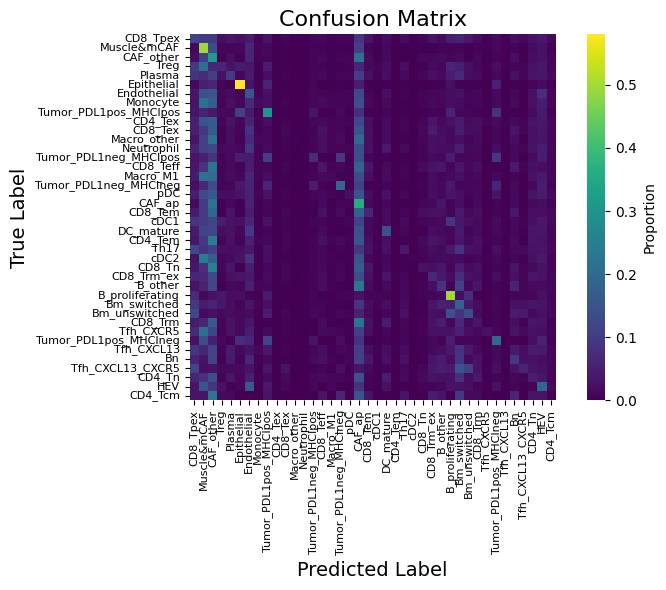

Computing confusion matrix...
Figure saved to NCRT/NCRT_project_all/result/conf_matrix_tumor1_level1_hce.pdf


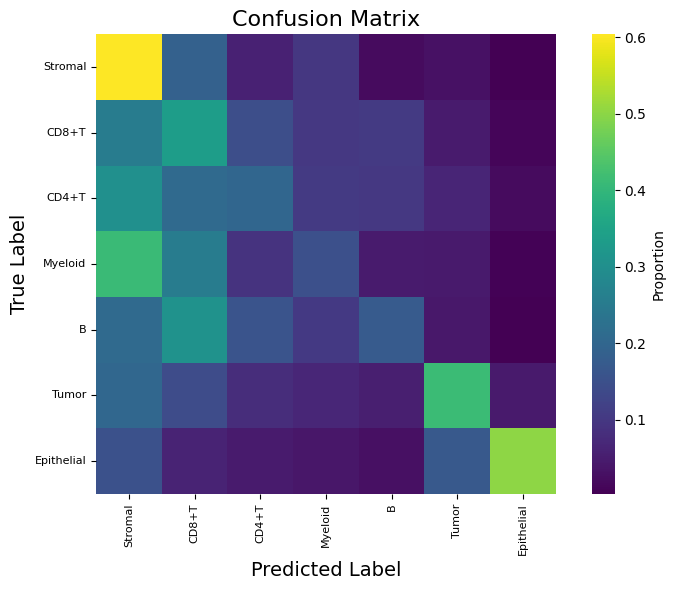

In [ ]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/confusion_tumor1_level2_hce.pdf',
    # save_path=None
)

# Level1 confusion matrix
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/confusion_tumor1_level1_hce.pdf',
    # save_path=None
)

In [ ]:
## Save validation metrics
metrics_csv_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/hce_lambda_validation_metrics.csv"

hce_lambda_used = hce_lambda if 'hce_lambda' in globals() else 0.5
metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=val_acc,
    val_macro_f1=val_macro_f1,
    val_weighted_f1=val_weighted_f1,
    val_level1_acc=val_level1_acc,
    val_level1_macro_f1=val_level1_macro_f1,
    val_level1_weighted_f1=val_level1_weighted_f1,
    class_names=class_names if 'class_names' in globals() else None,
    class_names_level1=class_names_level1 if 'class_names_level1' in globals() else None,
    best_epoch=best_epoch if 'best_epoch' in globals() else None,
    hce_lambda=hce_lambda_used,
    therapy_data=therapy_data,
    metrics_csv_path=metrics_csv_path
)

Current run metrics:
             timestamp therapy_data  best_epoch  hce_lambda  val_l2_accuracy  \
0  2026-03-24 17:55:27         NCRT           0         0.5          0.19124   

   val_l2_macro_f1  val_l2_weighted_f1  val_l1_accuracy  val_l1_macro_f1  \
0         0.076022            0.193235         0.369058         0.343748   

   val_l1_weighted_f1  num_l2_classes  num_l1_classes  
0            0.357119              40               7  

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/result/hce_lambda_validation_metrics.csv
Total rows: 4


Visualizing per-class performance...
  ✓ Computed metrics for 40 classes
Figure saved to NCRT/NCRT_project_all/result/f1_per_class_tumor1_level2_hce.pdf


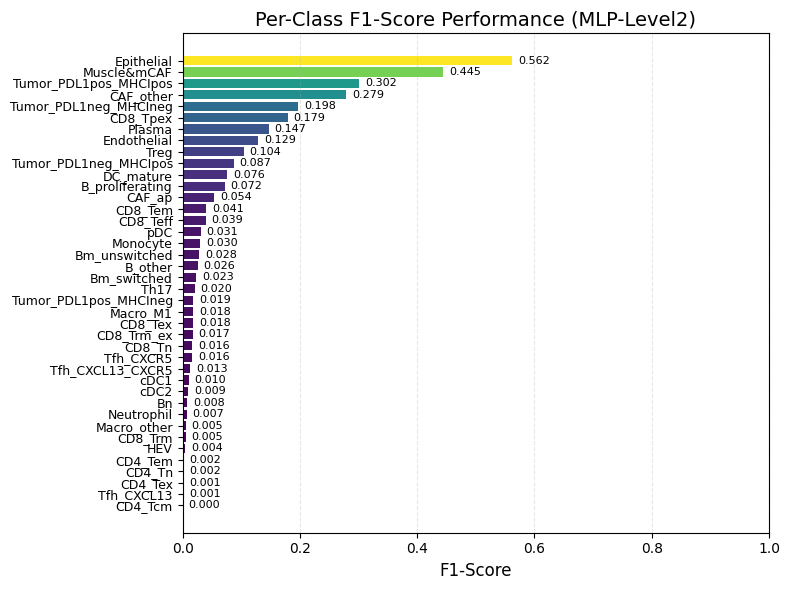


Model Summary:
  Device: cuda
  Training samples: 1222863
  Test samples: 524085
  Total classes (before filtering): 40
  Actual classes in test set: 40
  Feature dimension: 384
  Model parameters: 1,064,232
  Best epoch: 0
  Test Accuracy: 0.1912
  Test Macro F1: 0.0760
  Test Weighted F1: 0.1932
Visualizing per-class performance...
  ✓ Computed metrics for 7 classes
Figure saved to NCRT/NCRT_project_all/result/f1_per_class_tumor1_level1_hce.pdf


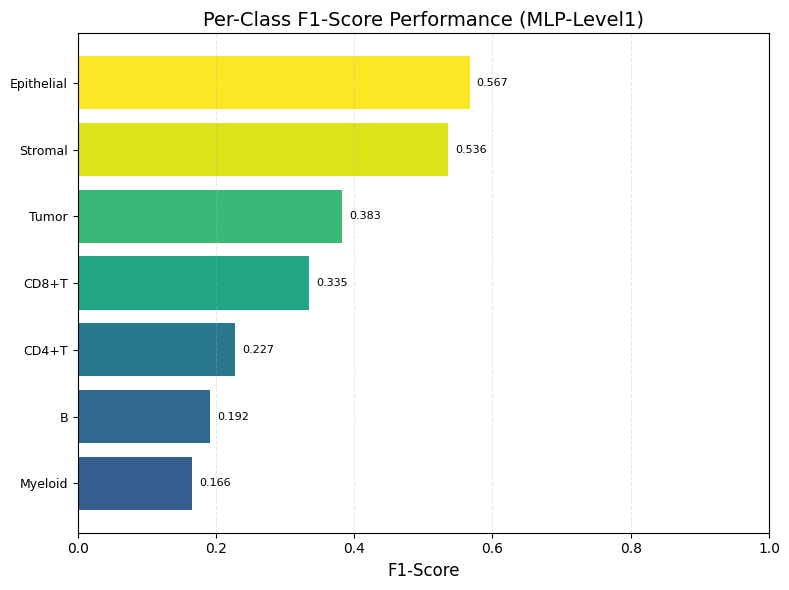


Model Summary:
  Device: cuda
  Training samples: 1222863
  Test samples: 524085
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 384
  Model parameters: 1,064,232
  Best epoch: 0
  Test Accuracy: 0.3691
  Test Macro F1: 0.3437
  Test Weighted F1: 0.3571


In [ ]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/f1_tumor1_level2_hce.pdf',
    # save_path=None
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/f1_tumor1_level1_hce.pdf',
    # save_path=None
)

Visualizing per-class accuracy...
  ✓ Computed metrics for 40 classes
Figure saved to NCRT/NCRT_project_all/result/acc_per_class_tumor1_level2_hce.pdf


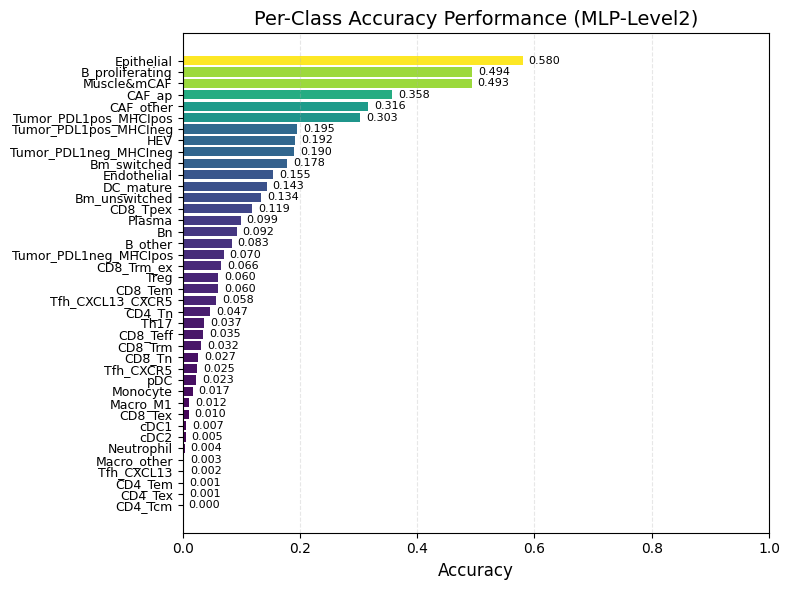


Model Summary:
  Device: cuda
  Training samples: 1222863
  Test samples: 524085
  Total classes (before filtering): 40
  Actual classes in test set: 40
  Feature dimension: 384
  Model parameters: 1,064,232
  Best epoch: 0
  Test Accuracy: 0.1912
  Test Macro F1: 0.0760
  Test Weighted F1: 0.1932
Visualizing per-class accuracy...
  ✓ Computed metrics for 7 classes
Figure saved to NCRT/NCRT_project_all/result/acc_per_class_tumor1_level1_hce.pdf


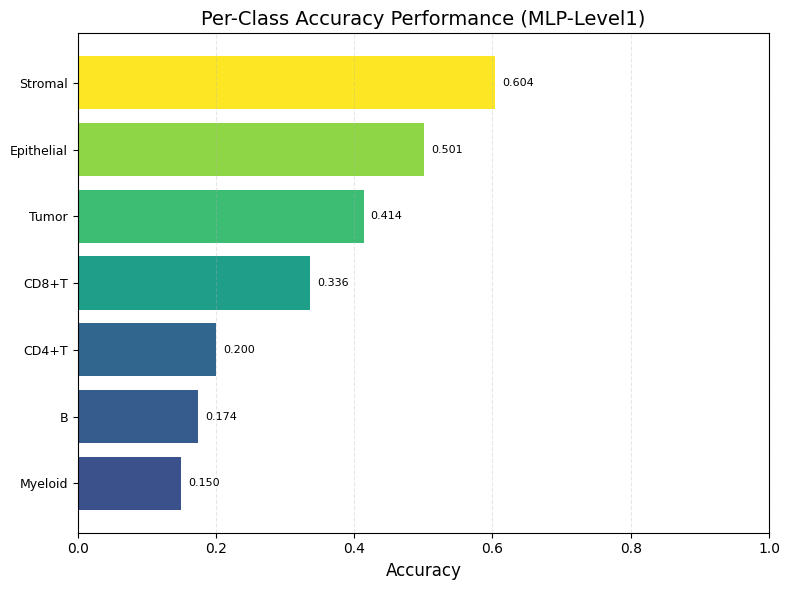


Model Summary:
  Device: cuda
  Training samples: 1222863
  Test samples: 524085
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 384
  Model parameters: 1,064,232
  Best epoch: 0
  Test Accuracy: 0.3691
  Test Macro F1: 0.3437
  Test Weighted F1: 0.3571


In [ ]:
# Per-class Accuracy for level2
metrics_acc_level2 = plot_per_class_accuracy(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level2_hce.pdf',
)

# Per-class Accuracy for level1
metrics_accuracy_level1 = plot_per_class_accuracy(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    save_path=f'{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level1_hce.pdf',
)

In [ ]:
# ## Evaluate on all data and plot spatial distribution
# all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
#     model=model,
#     matched_features_path=matched_features_path,
#     class_names=class_names,
#     evaluate=evaluate,
#     plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
#     CellTypeDataset=CellTypeDataset,
#     device=device,
#     scaler=scaler,
#     val_loader=val_loader if 'val_loader' in globals() else None,
#     X=X if 'X' in globals() else None,
#     y=y if 'y' in globals() else None,
#     y_encoded=y_encoded if 'y_encoded' in globals() else None,
#     X_train=X_train if 'X_train' in globals() else None,
#     X_train_scaled=X_train_scaled if 'X_train_scaled' in globals() else None,
#     X_test_scaled=X_test_scaled if 'X_test_scaled' in globals() else None,
#     y_train_encoded=y_train_encoded if 'y_train_encoded' in globals() else None,
#     y_test_encoded=y_test_encoded if 'y_test_encoded' in globals() else None,
#     min_samples_per_class=min_samples_per_class if 'min_samples_per_class' in globals() else 29,
#     X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
#     celltype_pred_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_valid_tumor1_level2_hce.jpg',
#     # celltype_pred_dir = None,
#     celltype_true_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level2_hce.jpg',
#     celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if 'celltype_pixel_NCRT_tumor1' in globals() else None,
#     spatial_figsize=(64, 48),
#     spatial_point_size=0.5,
# )

In [ ]:
# save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_valid_tumor1_level1_hce.jpg'
# save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'
# plot_level1_spatial_distribution(
#     matched_features_path=matched_features_path,
#     all_preds=all_preds,
#     class_names_level1=class_names_level1,
#     class_names=class_names,
#     y_encoded_f=y_encoded_f,
#     y_level1_encoded_f=y_level1_encoded_f,
#     plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
#     save_path_pred=save_path_pred,
#     save_path_true=save_path_true,
#     spatial_figsize=(64, 28),      
#     spatial_point_size=0.5,        
# )

## HE-feature validation

In [12]:
## From YuLu
# ## Option A: Using HIPT (recommended for quick start, no token required) - 6m57.2s
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/StarDist_nuclei_segmente.py \

In [ ]:
## Tumor1
# stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
# qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
# codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords.csv'
# save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist.csv'
# save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist_ViT.csv'

## All
stardist_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv'
qupath_corner_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv'
codex_meta_celltype_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
celltype_pixel_NCRT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all.csv'
save_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist.csv'
save_path4ViT = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_all_StarDist_ViT.csv'

In [8]:
celltype_anno_df, roi_cell_counts, star_coords_in_roi, celltype_pixel_NCRT = make_PCF2HE2StarDist_alignment(
    stardist_coords_path,
    qupath_corner_path,
    codex_meta_celltype_path,
    celltype_pixel_NCRT_path,
    therapy_data="NCRT",
    parent_value='all',
    save_path=save_path,
    save_path4ViT=save_path4ViT
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Hist2Pheno_pkg/base.py:3282: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCRT_tumor27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  star_coords.loc[mask, 'TumorID'] = name


Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCRT_tumor3', 'NCRT_tumor25']


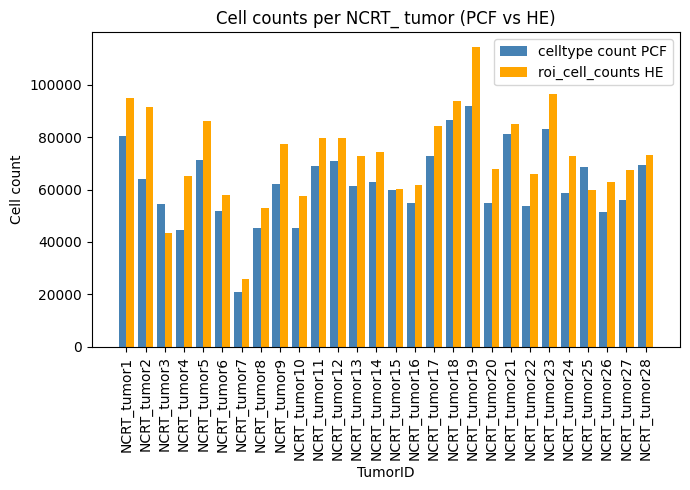

In [ ]:
# merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix='NCRT_', figure_size=(7,5),
#                         #  save_path=None)
#                         save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_{therapy_data}.pdf')

In [ ]:
# plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3', figure_size=(10,5),
#                     save_path=None)
#                 #    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor3.jpg')

In [ ]:
## Option A: Using HIPT (recommended for quick start, no token required) - 6m57.2s
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords_all_StarDist_ViT.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_all/ImgEmbeddings_all_stardist/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_all/ImgEmbeddings_all_stardist/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_all/ImgEmbeddings_all_stardist/ \
#    --scale 0.5  

## Predict StarDist

### Tumor 1

In [10]:
## Load best model for StarDist prediction.
therapy_model = f'{therapy_data}_project_all'
model_star = load_model_for_predict(path, therapy_data, therapy_model)

Loading best model for StarDist prediction...
✓ StarDist model loaded


In [ ]:
## All ROIs
# celltype_pixel_NCRT_stardist_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all_StarDist.csv'
# embedding_star_dir = Path(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_all_stardist/sc_pth_16_16")
# matched_features_star_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_all_stardist.npz"


## Tumor1
therapy_model = f'{therapy_data}_project_tumor1'
celltype_pixel_NCRT_stardist_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_tumor1_StarDist.csv'
embedding_star_dir = Path(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1_stardist/sc_pth_16_16")
matched_features_star_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_stardist.npz"

match_tolerance = 1.0
X_star, y_star, y_star_level1, X_coords_star = match_hist2cell_matrix(
    cell_coords_path=celltype_pixel_NCRT_stardist_path,
    hist_embedding_dir=embedding_star_dir,
    matched_features_path=matched_features_star_path,
    coord_cols=("centroid_x", "centroid_y"),   # StarDist coordinates
    tolerance=match_tolerance,
    pth_prefix=f"sc_{therapy_data}",
)

Loading celltype Ground Truth ...
  Loaded 77996 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz
  X shape: (77996, 384)
  y shape: (77996,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (77996, 2)


  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996,), dtype: <U21
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (77996, 384)
  No labels available - prediction mode only
X_all_scaled:  (77996, 384)
dummy_labels:  (77996,)
  ⚠ Large dataset detected (77996 samples). Setting num_workers=0 to avoid indexing issues.
  Total samples: 77996
  DataLoader batch_size: 1024, num_workers: 0
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 77/77 [00:01<00:00, 40.57it/s]



Prediction completed:
  Total predictions: 77996
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
  ✓ Using original labels for visualization: 77996 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.2687, macro_f1=0.0741, weighted_f1=0.2553

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996, 2)
  Coordinates shape: (77996, 2)
  Predictions shape: (77996,)
  ✓ Created prediction DataFrame with 77996 cells

Plotting spatial distribution of PREDICTED cell types...
Number of valid data points: 77996
Number of cell types: 40

Plotting spatial distribution of TRUE cell types (for comparison)...
Number of valid data points: 77996
Number of cell types: 40


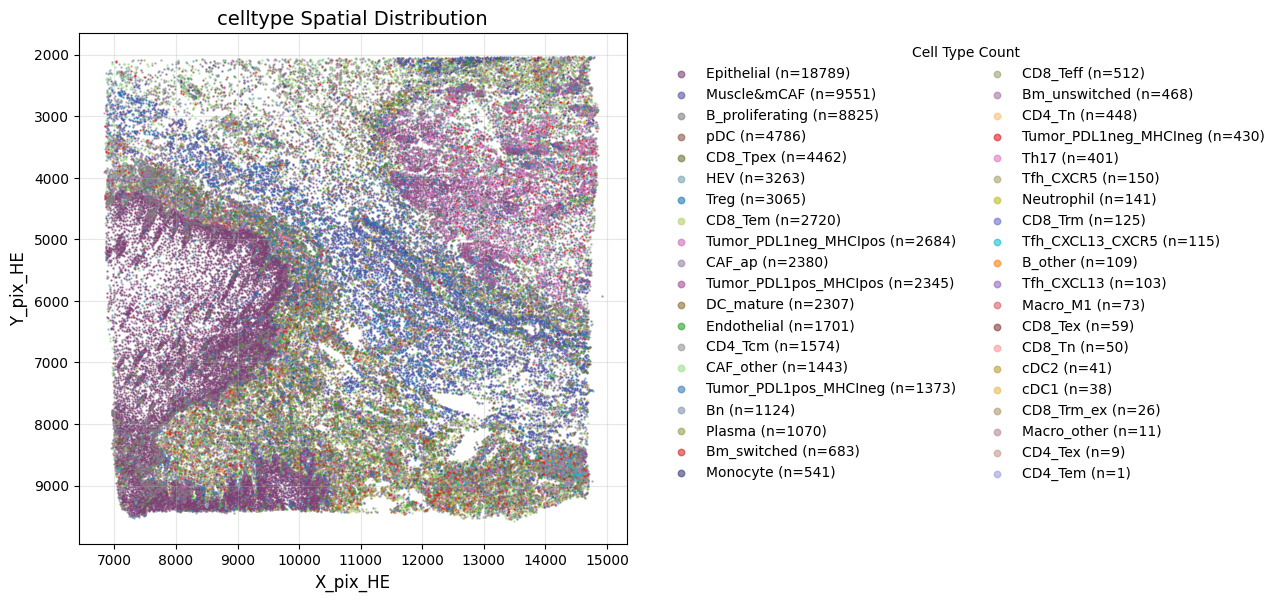

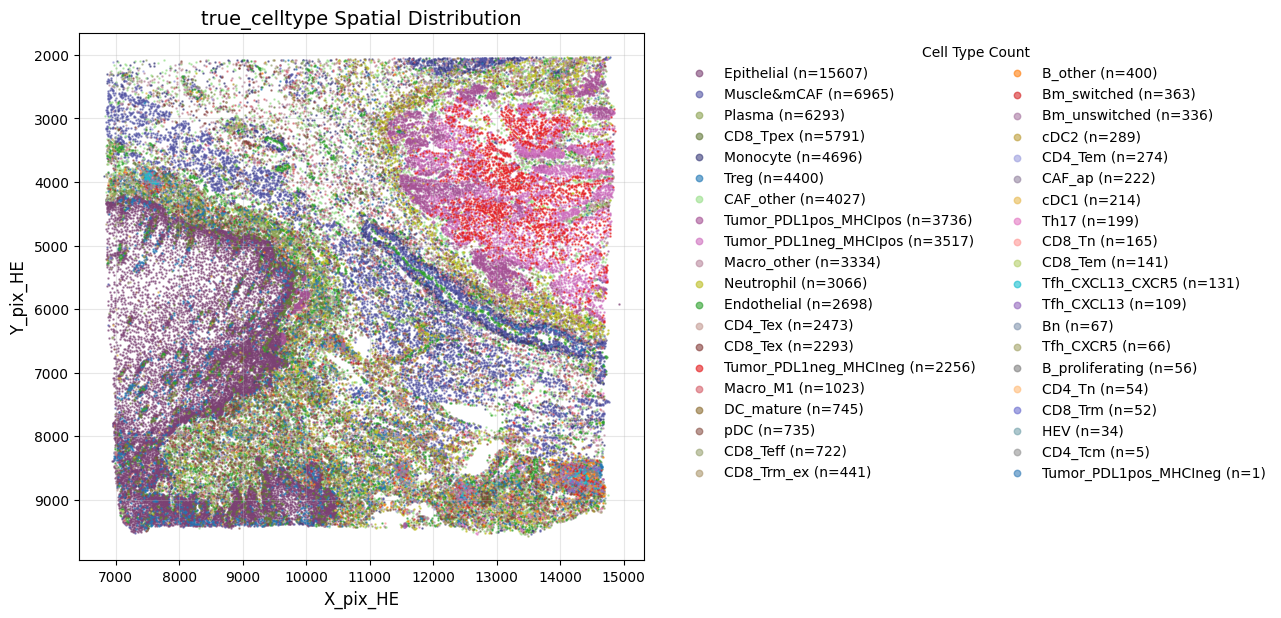

In [ ]:
# Predict on StarDist-matched data and plot spatial distribution (level2 + level1).
class_names_star = class_names if "class_names" in globals() and class_names is not None else [
    str(i) for i in range(num_classes_star)
]

all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_star_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    # Optional coordinate fallback when X_coords are missing in npz.
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    celltype_pred_dir=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level2_hce.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if "celltype_pixel_NCRT_stardist" in globals() else None,
)

In [12]:
print(type(all_preds), None if all_preds is None else all_preds.shape)
print(type(all_labels), all_labels)
print(all_acc, all_macro_f1, all_weighted_f1)

<class 'numpy.ndarray'> (77996,)
<class 'numpy.ndarray'> [ 6 26 24 ... 11  6 27]
0.2687445510026155 0.07408414458640686 0.25531185884796415


Number of valid data points: 77996
Number of cell types: 7
Number of valid data points: 77996
Number of cell types: 7
Saved StarDist level1 predicted/true spatial plots.


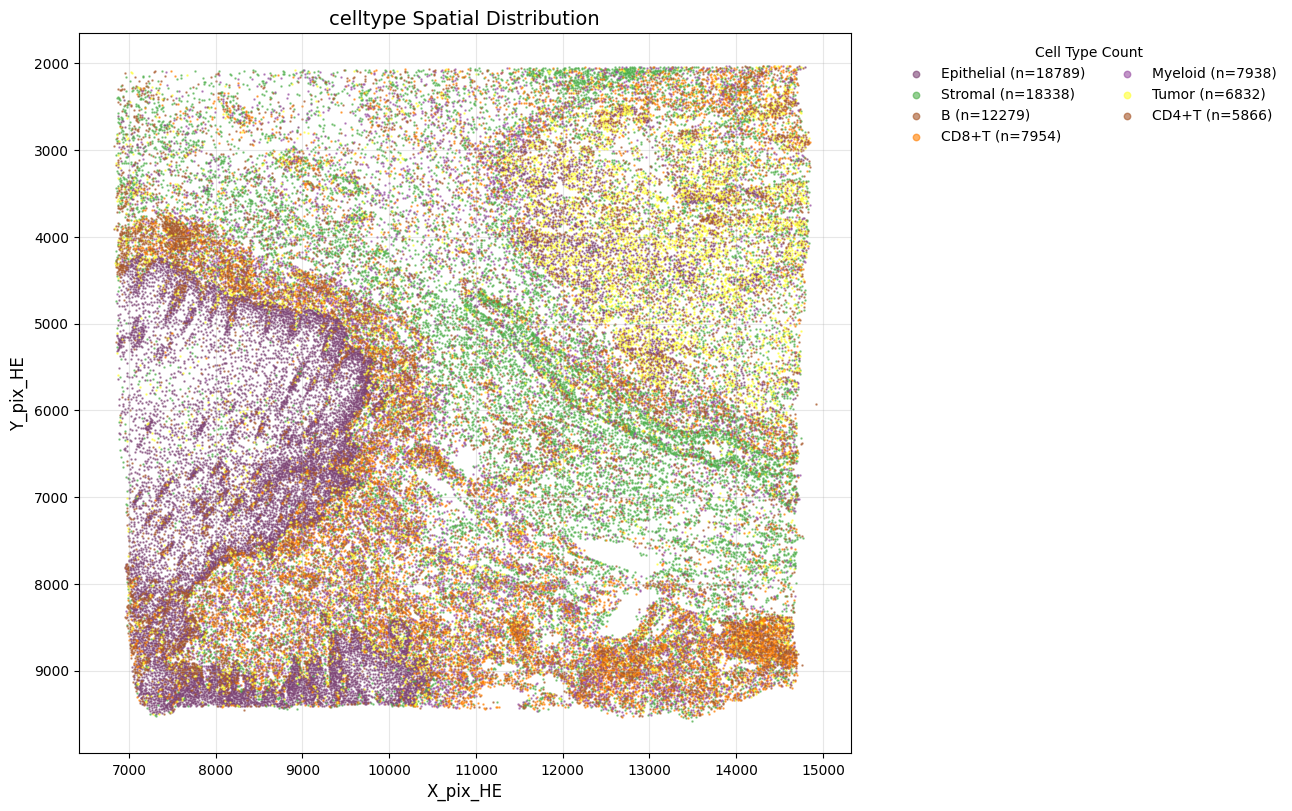

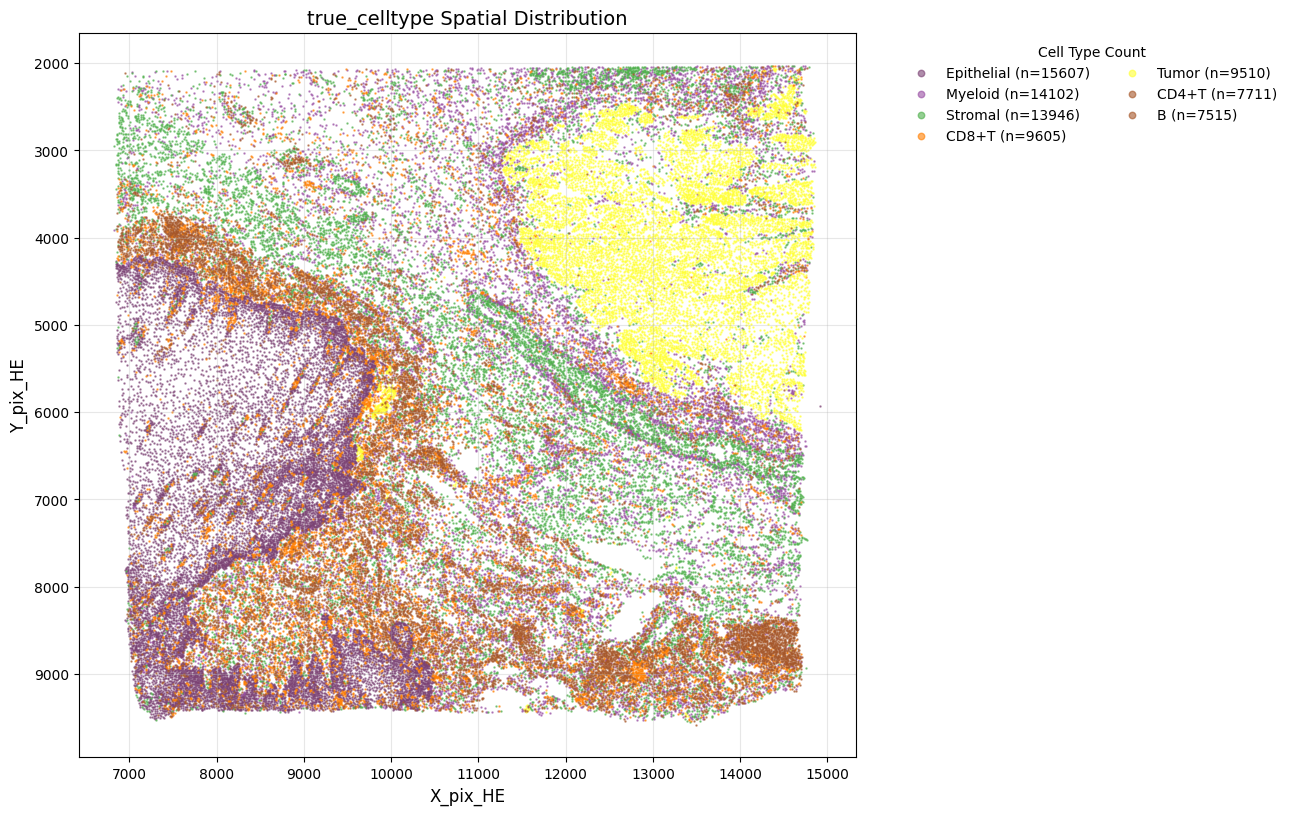

In [ ]:
save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level1_hce.jpg'
save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'

plot_level1_spatial_distribution(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=save_path_pred,
    save_path_true=save_path_true
)
print("Saved StarDist level1 predicted/true spatial plots.")

Visualizing per-class accuracy...
  ✓ Computed metrics for 40 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/result/acc_per_class_tumor1_level2_stardist_hce.pdf


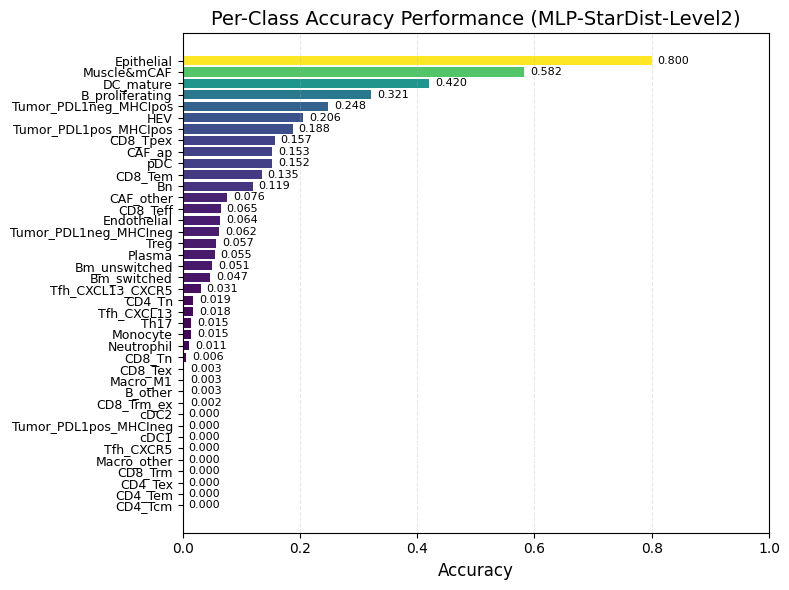


Model Summary:
  Device: cuda
  Total classes (before filtering): 40
  Actual classes in test set: 40
  Model parameters: 1,064,232
  Test Accuracy: 0.2687
  Test Macro F1: 0.0741
  Test Weighted F1: 0.2553
  Level1 metrics from level2 preds: acc=0.4023, macro_f1=0.3467, weighted_f1=0.3879
Visualizing per-class accuracy...
  ✓ Computed metrics for 7 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/result/acc_per_class_tumor1_level1_stardist_hce.pdf


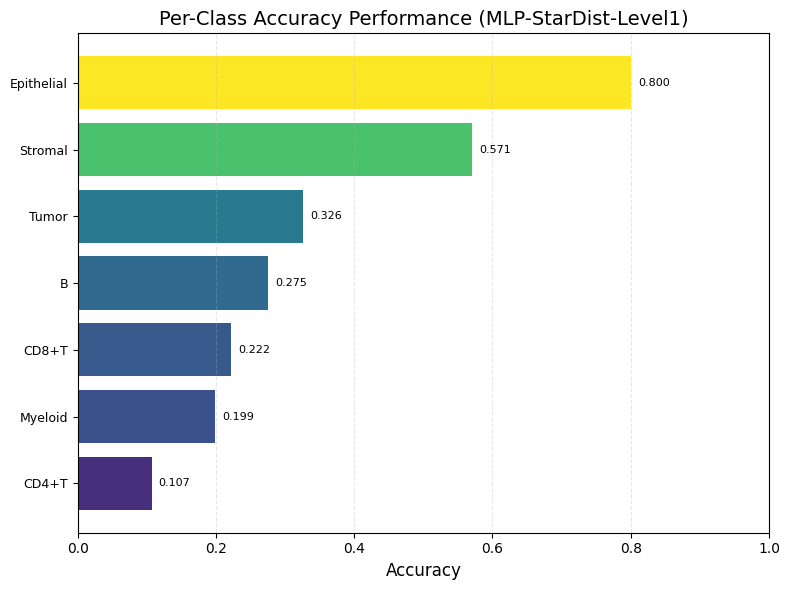


Model Summary:
  Device: cuda
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Model parameters: 1,064,232
  Test Accuracy: 0.4023
  Test Macro F1: 0.3467
  Test Weighted F1: 0.3879


In [ ]:
metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level2_stardist_hce.pdf',
)

metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names=class_names,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level1_stardist_hce.pdf',
)

### All

In [10]:
## Load best model for StarDist prediction.
therapy_model = f'{therapy_data}_project_all'
model_star = load_model_for_predict(path, therapy_data, therapy_model)

Loading best model for StarDist prediction...
✓ StarDist model loaded


In [11]:
## All ROIs
celltype_pixel_NCRT_stardist_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_all_StarDist.csv'
embedding_star_dir = Path(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_all_stardist/sc_pth_16_16")
matched_features_star_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_all_stardist.npz"


## Tumor1
# therapy_model = f'{therapy_data}_project_tumor1'
# celltype_pixel_NCRT_stardist_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_tumor1_StarDist.csv'
# embedding_star_dir = Path(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1_stardist/sc_pth_16_16")
# matched_features_star_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_stardist.npz"

match_tolerance = 1.0
X_star, y_star, y_star_level1, X_coords_star = match_hist2cell_matrix(
    cell_coords_path=celltype_pixel_NCRT_stardist_path,
    hist_embedding_dir=embedding_star_dir,
    matched_features_path=matched_features_star_path,
    coord_cols=("centroid_x", "centroid_y"),   # StarDist coordinates
    tolerance=match_tolerance,
    pth_prefix=f"sc_{therapy_data}",
)

Loading celltype Ground Truth ...
  Loaded 1690663 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/matched_features_all_stardist.npz
  X shape: (1690663, 384)
  y shape: (1690663,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (1690663, 2)


In [ ]:
# Predict on StarDist-matched data and plot spatial distribution (level2 + level1).
class_names_star = class_names if "class_names" in globals() and class_names is not None else [
    str(i) for i in range(num_classes_star)
]

all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_star_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    # Optional coordinate fallback when X_coords are missing in npz.
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    # celltype_pred_dir=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level2_hce.jpg',
    celltype_pred_dir=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_all_level2_hce.jpg',
    celltype_true_dir=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_all_level2_hce.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if "celltype_pixel_NCRT_stardist" in globals() else None,
    spatial_figsize=(64, 48),
    spatial_point_size=0.5,
)

  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/matched_features_all_stardist.npz: (1690663, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/matched_features_all_stardist.npz: (1690663,), dtype: <U21
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (1690663, 384)
  No labels available - prediction mode only
X_all_scaled:  (1690663, 384)
dummy_labels:  (1690663,)
  ⚠ Large dataset detected (1690663 samples). Setting num_workers=0 to avoid indexing issues.
  Total samples: 1690663
  DataLoader batch_size: 1024, num_workers: 0
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 1652/1652 [00:09<00:00, 172.27it/s]



Prediction completed:
  Total predictions: 1690663
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
  ✓ Using original labels for visualization: 1690663 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.1393, macro_f1=0.0559, weighted_f1=0.1519

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_all/matched_features_all_stardist.npz: (1690663, 2)
  Coordinates shape: (1690663, 2)
  Predictions shape: (1690663,)
  ✓ Created prediction DataFrame with 1690663 cells

Plotting spatial distribution of PREDICTED cell types...
Number of valid data points: 1690663
Number of cell types: 40

Plotting spatial distribution of TRUE cell types (for comparison)...
Number of valid data points: 1690663
Number of cell types: 40


In [ ]:
# save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_tumor1_level1_hce.jpg'
# save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_tumor1_level1_hce.jpg'
save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_pred_all_level1_hce.jpg'
save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/celltype_true_all_level1_hce.jpg'

plot_level1_spatial_distribution(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=save_path_pred,
    save_path_true=save_path_true,
    spatial_figsize=(64, 48),
    spatial_point_size=0.5,
)
print("Saved StarDist level1 predicted/true spatial plots.")

NameError: name 'path' is not defined

In [ ]:
metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level2_stardist_hce.pdf',
    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_all_level2_stardist_hce.pdf',
)

metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_star_path,
    all_preds=all_preds,
    class_names=class_names,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    # save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_tumor1_level1_stardist_hce.pdf',
    save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/{save_result}/acc_all_level1_stardist_hce.pdf',
)